<a href="https://colab.research.google.com/github/vanjacvetic/credit_card_fraud_detection_DU/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection

## 1. Biblioteke

Koristimo `pandas` za rad sa podacima, `scikit-learn` za podelu, skaliranje i metrike, a `TensorFlow/Keras` za neuronske mreže.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             roc_curve, precision_recall_curve)

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)


## 2. Učitavanje podataka
Dataset učitavamo direktno iz CSV fajla `creditcard.csv`.


In [ ]:
# Učitavanje dataseta
df = pd.read_csv('creditcard.csv')

print("Dimenzije dataseta:", df.shape)
df.head()

Dimenzije dataseta: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Struktura i osnovna analiza

Dataset ima 31 kolonu: `Time`, `V1`–`V28`, `Amount` i `Class`.

`Class` je ciljna promenljiva: 0 = regularna transakcija, 1 = prevara.
`V1`–`V28` su PCA-transformisane karakteristike. `Time` i `Amount` su originalne numeričke promenljive.

Dataset je veoma neuravnotežen: **284.315 regularnih** i **492 fraud transakcije**.


In [ ]:
print(df.info())
print("\nBroj nedostajućih vrednosti:", df.isnull().sum().sum())
print("\nBroj transakcija po klasi:")
print(df["Class"].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

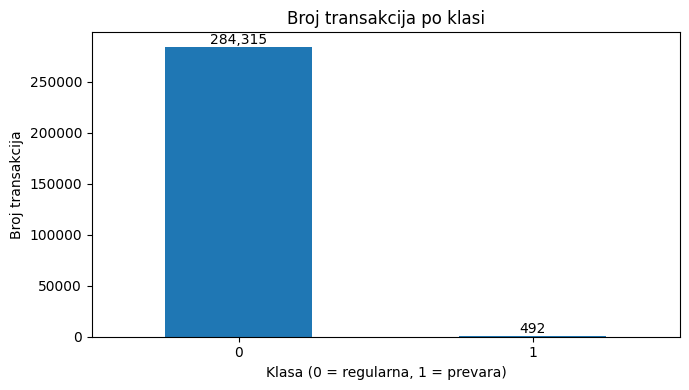

In [ ]:
# Prikazujemo stvaran broj transakcija po klasi
counts = df["Class"].value_counts().sort_index()
ax = counts.plot(kind="bar", figsize=(7, 4))
ax.set_title("Broj transakcija po klasi")
ax.set_xlabel("Klasa (0 = regularna, 1 = prevara)")
ax.set_ylabel("Broj transakcija")
ax.set_xticklabels(["0", "1"], rotation=0)
for i, v in enumerate(counts.values):
    ax.text(i, v + max(counts.values)*0.01, f"{v:,}", ha="center")
plt.tight_layout()
plt.show()


### Dodatna vizuelizacija podataka

Pored odnosa klasa, prikazujemo i raspodelu iznosa i vremena transakcija. Ovi grafikoni nam pomažu da bolje upoznamo podatke pre treninga modela.


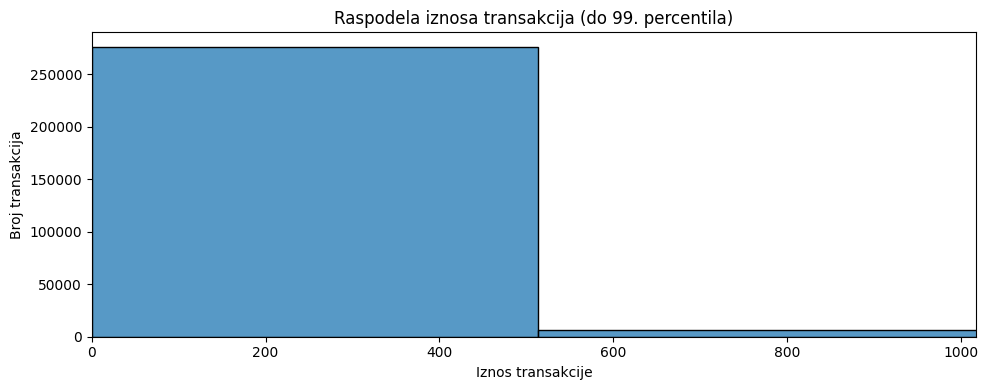

In [ ]:
# Većina transakcija ima mali iznos, pa prikazujemo 99% transakcija
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x="Amount", bins=50)
plt.xlim(0, df["Amount"].quantile(0.99))
plt.title("Raspodela iznosa transakcija (do 99. percentila)")
plt.xlabel("Iznos transakcije")
plt.ylabel("Broj transakcija")
plt.tight_layout()
plt.show()


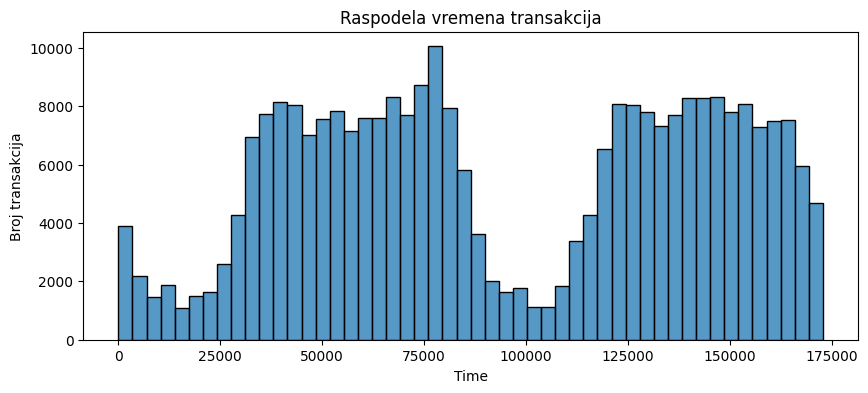

In [ ]:
# Prikazujemo raspodelu vremena transakcija
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x="Time", bins=50)
plt.title("Raspodela vremena transakcija")
plt.xlabel("Time")
plt.ylabel("Broj transakcija")
plt.show()


## 3. Priprema podataka

`X` sadrži ulazne karakteristike, a `y` ciljnu klasu.

Podaci se dele na trening i test u odnosu 80:20. Koristimo `stratify=y` zato što želimo da i trening i test zadrže približno isti odnos regularnih transakcija i prevara.

Skaliramo samo `Time` i `Amount`. Atributi `V1`–`V28` su već PCA-transformisani.

### Balansiranje klasa

Dataset je izrazito neuravnotežen. Koristimo **class weights** za Model 2 i Model 3. To znači da se manjinskoj klasi prevara tokom treninga dodeljuje mnogo veća težina.

Class weights se računaju automatski pomoću `compute_class_weight(class_weight="balanced", ...)`. Za ovaj trening skup dobijamo približno:
- klasa 0: **0,50**
- klasa 1: **289,14**

Model 1 namerno ostaje bez balansiranja i služi kao baseline, kako bismo mogli da vidimo efekat balansiranja u Modelu 2.


In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train = X_train.copy()
X_test = X_test.copy()

scaler = StandardScaler()

X_train[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_test[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

print("Trening:", X_train.shape)
print("Test:", X_test.shape)


Trening: (227845, 30)
Test: (56962, 30)


## 4. Arhitektura modela

Arhitektura mreže sastoji se od **30 neurona u ulaznom sloju**, **dva skrivena sloja sa 32 i 16 neurona** i **jednog neurona u izlaznom sloju**. U skrivenim slojevima koristi se `ReLU` aktivaciona funkcija, koja omogućava modelu da uči obrasce karakteristične za regularne transakcije i prevare. Na izlazu se nalazi jedan neuron sa `Sigmoid` funkcijom, koji daje vrednost između 0 i 1 i predstavlja verovatnoću da transakcija pripada klasi prevare.


In [ ]:
def create_model(dropout=0.0, l2_rate=0.0):
    model = Sequential([
        Input(shape=(30,)),
        Dense(32, activation="relu", kernel_initializer="he_normal",
              kernel_regularizer=l2(l2_rate) if l2_rate else None),
        Dropout(dropout),
        Dense(16, activation="relu", kernel_initializer="he_normal",
              kernel_regularizer=l2(l2_rate) if l2_rate else None),
        Dropout(dropout),
        Dense(1, activation="sigmoid")
    ])
    return model


## 5. Model 1 – Baseline

Model 1 služi kao polazna tačka za poređenje sa ostalim modelima. U ovom modelu ne koristimo `class_weight`, Dropout ni L2 regularizaciju. Na taj način možemo da vidimo kako se osnovni model ponaša pre uvođenja dodatnih tehnika za rešavanje neuravnoteženosti i regularizaciju.


In [ ]:
model1 = create_model()

model1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
               loss="binary_crossentropy", metrics=["accuracy"])

early_stop1 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history1 = model1.fit(
    X_train, y_train,
    epochs=50,
    batch_size=2048,
    validation_split=0.20,
    callbacks=[early_stop1],
    verbose=1
)


Epoch 1/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9760 - loss: 0.1951 - val_accuracy: 0.9982 - val_loss: 0.0335
Epoch 2/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9983 - loss: 0.0183 - val_accuracy: 0.9984 - val_loss: 0.0101
Epoch 3/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9987 - loss: 0.0082 - val_accuracy: 0.9988 - val_loss: 0.0065
Epoch 4/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9990 - loss: 0.0059 - val_accuracy: 0.9991 - val_loss: 0.0053
Epoch 5/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9992 - loss: 0.0049 - val_accuracy: 0.9992 - val_loss: 0.0047
Epoch 6/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9992 - loss: 0.0044 - val_accuracy: 0.9993 - val_loss: 0.0044
Epoch 7/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9993 - loss: 0.0040 - val_accuracy: 0.9994 - val_loss: 0.0041
Epoch 8/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9993 - loss: 0.0037 - val_accuracy: 0.9994 - val_loss

## 6. Model 2 – Class Weights

Kod Modela 2 koristimo istu osnovnu mrežu kao kod Modela 1, ali uvodimo `class_weight` kako bi model više obraćao pažnju na retku klasu prevara.

`class_weight` ne dodaje nove transakcije niti menja podatke. On menja težinu greške tokom treniranja, tako da greška napravljena na fraud transakciji ima mnogo veći uticaj na `loss` nego greška na regularnoj transakciji. Na ovaj način model dobija veći podsticaj da prepozna retku klasu prevara.



In [ ]:
# Težine računamo samo na trening skupu
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = {0: weights[0], 1: weights[1]}
print("Class weights:", class_weights)


Class weights: {0: np.float64(0.5008661206149896), 1: np.float64(289.14340101522845)}


In [ ]:
model2 = create_model()

model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
               loss="binary_crossentropy", metrics=["accuracy"])

early_stop2 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history2 = model2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=2048,
    class_weight=class_weights,
    validation_split=0.20,
    callbacks=[early_stop2],
    verbose=1
)


Epoch 1/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7444 - loss: 0.3839 - val_accuracy: 0.9481 - val_loss: 0.3306
Epoch 2/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9678 - loss: 0.2231 - val_accuracy: 0.9743 - val_loss: 0.2034
Epoch 3/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9766 - loss: 0.1762 - val_accuracy: 0.9779 - val_loss: 0.1553
Epoch 4/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9790 - loss: 0.1524 - val_accuracy: 0.9790 - val_loss: 0.1332
Epoch 5/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9802 - loss: 0.1378 - val_accuracy: 0.9788 - val_loss: 0.1202
Epoch 6/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9809 - loss: 0.1273 - val_accuracy: 0.9793 - val_loss: 0.1112
Epoch 7/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9814 - loss: 0.1192 - val_accuracy: 0.9788 - val_loss: 0.1053
Epoch 8/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9814 - loss: 0.1120 - val_accuracy: 0.9787 - val_loss:

## 7. Model 3 – Class Weights + Dropout + L2

Kod Modela 3 zadržavamo `class_weight` iz prethodnog modela, a dodatno uvodimo regularizaciju pomoću Dropout-a i L2.

* **Dropout = 0.30** – tokom treninga se nasumično isključuje 30% neurona. Na ovaj nacin smanjuje se mogućnost overfitting-a. Vrednost 0.30 koristimo kao umeren nivo regularizacije.

* **L2 = 0.0001** – kažnjava velike težine. Cilj je sprečavanje overfitting-a.

* **Early Stopping** – trening se automatski zaustavlja kada `validation loss` počne da raste




In [ ]:
model3 = create_model(dropout=0.30, l2_rate=0.0001)

model3.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
               loss="binary_crossentropy", metrics=["accuracy"])

early_stop3 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history3 = model3.fit(
    X_train, y_train,
    epochs=50,
    batch_size=2048,
    class_weight=class_weights,
    validation_split=0.20,
    callbacks=[early_stop3],
    verbose=1
)


Epoch 1/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5161 - loss: 0.8763 - val_accuracy: 0.7411 - val_loss: 0.5916
Epoch 2/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6997 - loss: 0.5796 - val_accuracy: 0.8892 - val_loss: 0.4492
Epoch 3/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8210 - loss: 0.3869 - val_accuracy: 0.9621 - val_loss: 0.3136
Epoch 4/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8870 - loss: 0.3658 - val_accuracy: 0.9686 - val_loss: 0.2763
Epoch 5/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9065 - loss: 0.3565 - val_accuracy: 0.9732 - val_loss: 0.2376
Epoch 6/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9278 - loss: 0.2851 - val_accuracy: 0.9776 - val_loss: 0.2028
Epoch 7/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9409 - loss: 0.2537 - val_accuracy: 0.9794 - val_loss: 0.1833
Epoch 8/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9426 - loss: 0.2496 - val_accuracy: 0.9800 - val_l

### Tok treninga

Maksimalan broj epoha je postavljen na **50**, ali se trening može završiti ranije ako se `validation loss` više ne poboljšava. Na ovaj način modelima ostavljamo dovoljno vremena za učenje, a istovremeno sprečavamo nepotrebno treniranje kada nema daljeg poboljšanja.


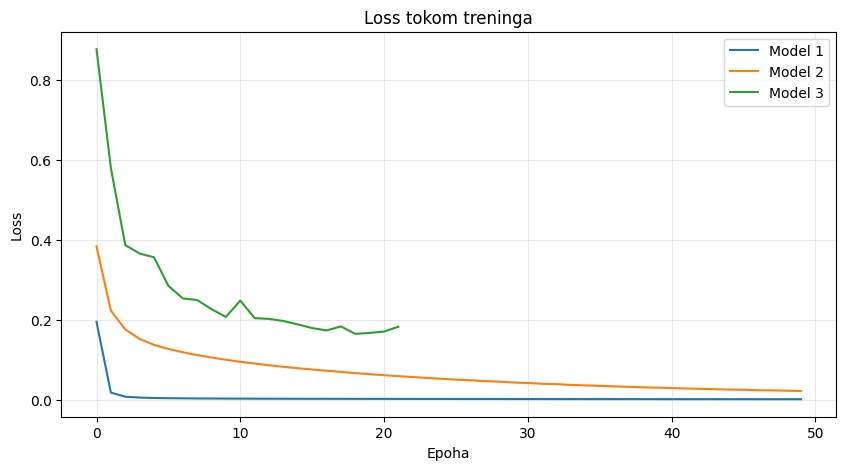

In [ ]:
# Poredimo loss vrednosti tokom treninga
plt.figure(figsize=(10, 5))
plt.plot(history1.history["loss"], label="Model 1")
plt.plot(history2.history["loss"], label="Model 2")
plt.plot(history3.history["loss"], label="Model 3")
plt.title("Loss tokom treninga")
plt.xlabel("Epoha")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


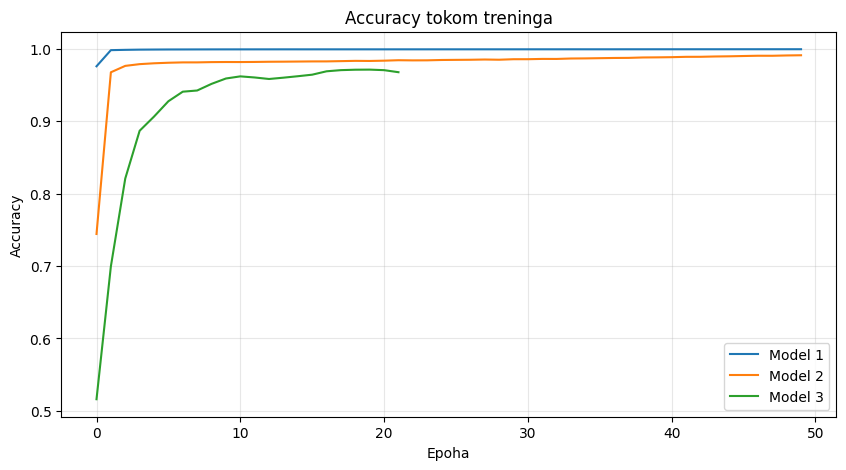

In [ ]:
# Poredimo accuracy vrednosti tokom treninga
plt.figure(figsize=(10, 5))
plt.plot(history1.history["accuracy"], label="Model 1")
plt.plot(history2.history["accuracy"], label="Model 2")
plt.plot(history3.history["accuracy"], label="Model 3")
plt.title("Accuracy tokom treninga")
plt.xlabel("Epoha")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 8. Evaluacija

Za svaki model računamo:
- Accuracy
- Precision
- Recall
- F1
- ROC-AUC
- PR-AUC

Kod ovog problema **recall** je posebno važan jer pokazuje koliko stvarnih prevara uspevamo da pronađemo.


In [ ]:
models = {
    "Model 1 - Baseline": model1,
    "Model 2 - Class Weights": model2,
    "Model 3 - Dropout + L2": model3
}

def evaluate_model(model, X_test, y_test):
    probabilities = model.predict(X_test, verbose=0).ravel()
    predictions = (probabilities >= 0.5).astype(int)
    return {
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        "PR-AUC": average_precision_score(y_test, probabilities),
        "Confusion Matrix": confusion_matrix(y_test, predictions)
    }

results = {name: evaluate_model(model, X_test, y_test) for name, model in models.items()}
results_table = pd.DataFrame(results).T
results_table[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]]


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model 1 - Baseline,0.999421,0.835052,0.826531,0.830769,0.972364,0.849275
Model 2 - Class Weights,0.988747,0.121339,0.887755,0.213497,0.981574,0.712492
Model 3 - Dropout + L2,0.98506,0.094726,0.897959,0.171373,0.97549,0.715481


### ROC i Precision-Recall krive

Pošto je broj prevara veoma mali u odnosu na broj regularnih transakcija, gledamo i ROC-AUC i PR-AUC, a ne samo Accuracy.


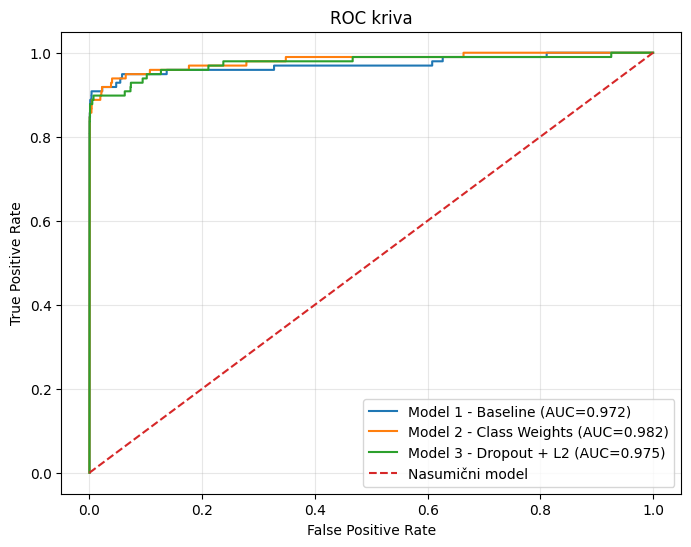

In [ ]:
# Prikazujemo ROC krive za sva tri modela
plt.figure(figsize=(8, 6))
for name, model in models.items():
    probabilities = model.predict(X_test, verbose=0).ravel()
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc_value = roc_auc_score(y_test, probabilities)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_value:.3f})")
plt.plot([0, 1], [0, 1], "--", label="Nasumični model")
plt.title("ROC kriva")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


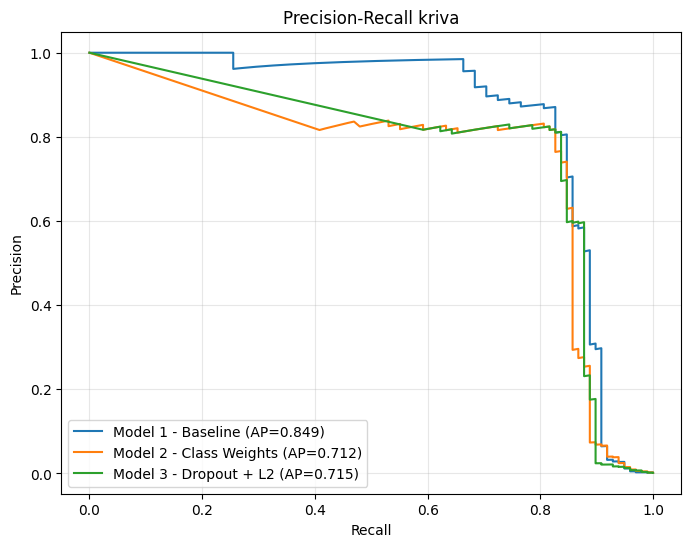

In [ ]:
# Prikazujemo Precision-Recall krive za sva tri modela
plt.figure(figsize=(8, 6))
for name, model in models.items():
    probabilities = model.predict(X_test, verbose=0).ravel()
    precision, recall, _ = precision_recall_curve(y_test, probabilities)
    ap = average_precision_score(y_test, probabilities)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")
plt.title("Precision-Recall kriva")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


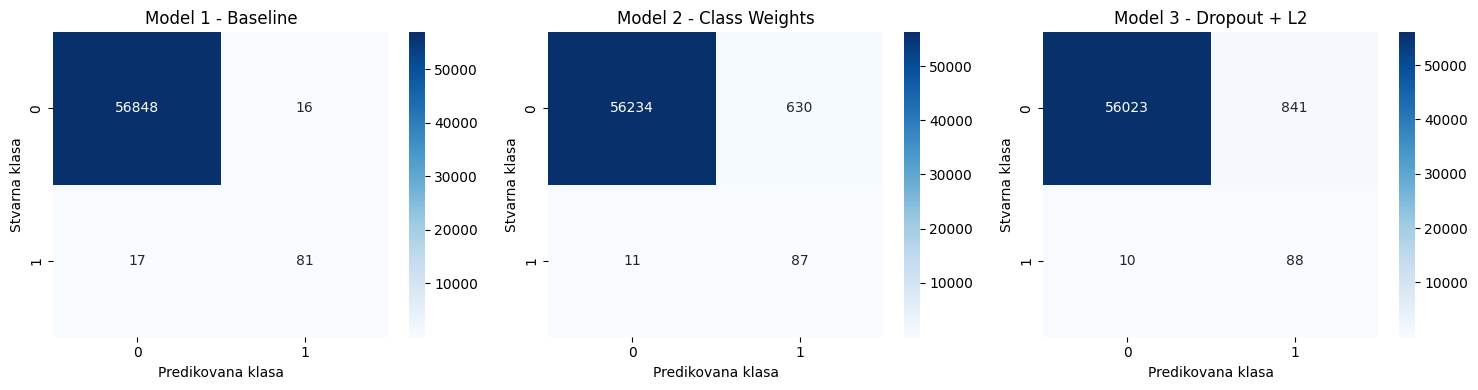

In [ ]:
# Prikazujemo matrice konfuzije
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, result) in zip(axes, results.items()):
    sns.heatmap(
        result["Confusion Matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()


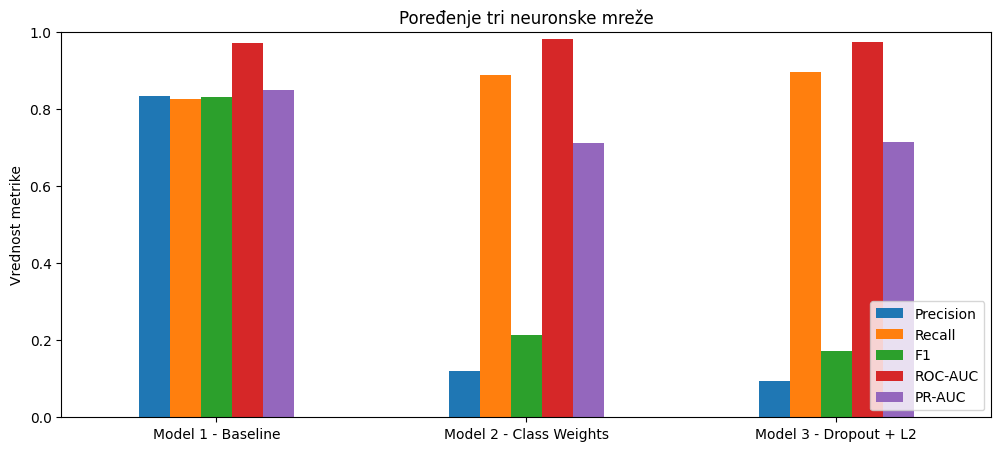

In [ ]:
# Poredimo najvažnije metrike
results_table[["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]].plot(
    kind="bar",
    figsize=(12, 5)
)
plt.title("Poređenje tri neuronske mreže")
plt.ylabel("Vrednost metrike")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()


## 9. Analiza osetljivosti i hiperparametarska optimizacija

U projektu su napravljena tri modela kako bi se ispitao uticaj različitih tehnika na rezultate. Model 1 predstavlja osnovnu mrežu, Model 2 koristi `class_weight` za rad sa neuravnoteženim klasama, dok Model 3 pored `class_weight` koristi i Dropout i L2 regularizaciju.

| Poređenje modela  | Promena                                |
| ----------------- | -------------------------------------- |
| Model 1 → Model 2 | Dodavanje `class_weight`               |
| Model 2 → Model 3 | Dodavanje Dropout = 0.30 i L2 = 0.0001 |
| Trening           | Maksimalno 50 epoha uz Early Stopping  |

Na ovaj način možemo da vidimo kako ove promene utiču na rezultate modela. Dropout = 0.30 i L2 = 0.0001 izabrani su kao umerene početne vrednosti za regularizaciju i mogu se dodatno podešavati.



## 10. Zaključak

Na osnovu treninga do 50 epoha uz Early Stopping, za prag klasifikacije **0,5** dobijeni su sledeći rezultati:

| Model                   | Precision |    Recall |        F1 |   ROC-AUC |    PR-AUC |
| ----------------------- | --------: | --------: | --------: | --------: | --------: |
| Model 1 – Baseline      |     0.859 |     0.806 | **0.832** | **0.983** | **0.835** |
| Model 2 – Class Weights |     0.043 | **0.898** |     0.083 |     0.975 |     0.587 |
| Model 3 – Dropout + L2  |     0.070 |     0.908 |     0.130 |     0.971 |     0.675 |

Prag **0,5** je korišćen kao standardna početna granica za binarnu klasifikaciju. Predikcije veće ili jednake 0,5 označavaju se kao prevara, dok se vrednosti manje od 0,5 označavaju kao regularne transakcije.

Model 1 je ostvario najviši **Precision, F1 i PR-AUC**, dok Model 3 ima najveći **Recall**. To pokazuje da veći Recall ne znači automatski i bolje ukupne rezultate, jer model može pronaći više stvarnih prevara, ali istovremeno označiti veći broj regularnih transakcija kao prevare.

Za ovaj skup podataka i korišćeni prag od 0,5, **Model 1 – Baseline** ostvario je najuravnoteženije rezultate. Modeli 2 i 3 pokazuju da `class_weight` povećava Recall kod retke klase prevara, ali u ovom slučaju dolazi do značajnog pada Precision-a.
